## Lanjutan:

Sel kode pertama di bawah ini memuat kembali `df_berita` hasil crawling dari file `df_berita_hasil_crawling.csv` yang disimpan oleh notebook Tahap 1, sehingga notebook ini bisa dijalankan tanpa harus mengulang proses crawling. Jika file CSV tersebut belum ada (misalnya notebook Tahap 1 belum dijalankan), maka digunakan data contoh (dummy) sebagai pengganti agar seluruh alur (Tahap 2 dst.) tetap bisa didemonstrasikan.

In [1]:
import os
import re
import pandas as pd

CSV_PATH = 'df_berita_hasil_crawling.csv'

if os.path.exists(CSV_PATH):
    df_berita = pd.read_csv(CSV_PATH, index_col='No')
    print(f"Berhasil memuat df_berita dari '{CSV_PATH}'")
else:
    print(f"File '{CSV_PATH}' tidak ditemukan -> menggunakan data contoh (dummy).")
    from sample_data import SAMPLE_BERITA
    df_berita = pd.DataFrame(
        [{'Judul Berita': j, 'Tautan': t} for j, t in SAMPLE_BERITA]
    )
    df_berita.index = range(1, len(df_berita) + 1)
    df_berita.index.name = 'No'

# =========================================================
# Kolom 'Kategori' dipakai sebagai TARGET untuk klasifikasi
# (mis. di Orange: drag kolom ini ke kotak "Target").
# Jika file CSV sudah punya kolom 'Kategori' (hasil crawling asli
# dari detik.com, mis. 'health'/'sport'), pakai itu langsung.
# Kalau belum ada, baru diekstrak dari segmen pertama URL.
# =========================================================
if 'Kategori' not in df_berita.columns:
    def ekstrak_kategori(url: str) -> str:
        m = re.search(r'https?://[^/]+/([^/]+)/', str(url))
        return m.group(1) if m else 'lainnya'
    df_berita['Kategori'] = df_berita['Tautan'].apply(ekstrak_kategori)

print("Jumlah data berita:", len(df_berita))
print("Jumlah kategori unik:", df_berita['Kategori'].nunique())
print("\nDistribusi kategori:")
print(df_berita['Kategori'].value_counts())
df_berita.head()

Berhasil memuat df_berita dari 'df_berita_hasil_crawling.csv'
Jumlah data berita: 200
Jumlah kategori unik: 2

Distribusi kategori:
Kategori
health    100
sport     100
Name: count, dtype: int64


,Judul Berita,Tautan,Kategori
No,,,
1,"Susul Italia, Denmark Juga Di-lockdown Imbas V...",https://health.detik.com/berita-detikhealth/d-...,health
2,Mungkinkah Virus Corona Aktif Lagi Setelah Pas...,https://health.detik.com/berita-detikhealth/d-...,health
3,"Sebaran Kasus Corona RI 9 Juni, 11.414 Sembuh ...",https://health.detik.com/berita-detikhealth/d-...,health
4,"Kisah Pasien 03, Buka-bukaan Awal Tertular Vir...",https://health.detik.com/berita-detikhealth/d-...,health
5,4 Variasi Seks Ketika Penetrasi Biasa Terasa M...,https://health.detik.com/sexual-health/d-49477...,health


## Tahap 2: Text Preprocessing, Ekstraksi Fitur (TF-IDF), dan Reduksi Dimensi (PCA)

Setelah data berita berhasil di-*crawl* pada tahap sebelumnya (`df_berita`), tahap selanjutnya adalah:

1. **Preprocessing** teks judul berita (cleaning, case folding, tokenizing, stopword removal, stemming).
2. **Ekstraksi fitur**, yaitu membangun kosakata (seluruh kata unik) dari korpus hasil preprocessing.
3. **Representasi TF-IDF**, mengubah setiap dokumen (judul berita) menjadi vektor numerik berbobot TF-IDF.
4. **Reduksi dimensi** matriks TF-IDF menggunakan **PCA (Principal Component Analysis)** agar bisa divisualisasikan dan dianalisis lebih lanjut.

### 1. Text Preprocessing

Tahapan pembersihan teks yang dilakukan pada setiap judul berita:

- **Case folding**: mengubah seluruh teks menjadi huruf kecil.
- **Cleaning**: menghapus angka, tanda baca, dan karakter selain huruf.
- **Tokenizing**: memecah kalimat menjadi kata-kata (token).
- **Stopword removal**: membuang kata-kata umum Bahasa Indonesia yang tidak informatif (contoh: *yang, di, dan, untuk*).
- **Stemming**: mengubah kata berimbuhan menjadi kata dasar (menggunakan **Sastrawi**, library stemmer Bahasa Indonesia paling umum digunakan). Jika library belum terpasang, jalankan `!pip install Sastrawi` terlebih dahulu.

In [2]:
# Install Sastrawi jika belum tersedia (khusus stemming Bahasa Indonesia)
# Jalankan baris di bawah ini sekali saja jika belum pernah diinstall
# !pip install Sastrawi

import re
import pandas as pd

# --- Daftar stopword Bahasa Indonesia ---
# Diutamakan menggunakan stopword bawaan Sastrawi (lebih lengkap & terpercaya).
# Jika Sastrawi belum terpasang, dipakai daftar stopword manual sebagai fallback.
try:
    from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
    from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

    stopword_factory = StopWordRemoverFactory()
    daftar_stopword = set(stopword_factory.get_stop_words())

    stemmer_factory = StemmerFactory()
    stemmer = stemmer_factory.create_stemmer()

    SASTRAWI_TERSEDIA = True
    print("Sastrawi berhasil dimuat. Stopword removal & stemming menggunakan Sastrawi.")

except ImportError:
    SASTRAWI_TERSEDIA = False

    # Fallback stemmer sederhana (rule-based) jika Sastrawi belum terpasang.
    # Tidak seakurat Sastrawi, namun tetap mampu memotong imbuhan umum
    # Bahasa Indonesia (awalan & akhiran) agar kata mendekati bentuk dasarnya.
    _PREFIXES = ['meng', 'meny', 'men', 'mem', 'me', 'peng', 'peny', 'pen', 'pem', 'pe',
                 'ber', 'ter', 'di', 'ke', 'se']
    _SUFFIXES = ['kan', 'an', 'i', 'nya', 'lah', 'kah', 'ku', 'mu']

    class SimpleStemmer:
        def stem(self, kata):
            asal = kata
            for sfx in sorted(_SUFFIXES, key=len, reverse=True):
                if kata.endswith(sfx) and len(kata) - len(sfx) >= 3:
                    kata = kata[: -len(sfx)]
                    break
            for pfx in sorted(_PREFIXES, key=len, reverse=True):
                if kata.startswith(pfx) and len(kata) - len(pfx) >= 3:
                    kata = kata[len(pfx):]
                    break
            return kata if len(kata) >= 3 else asal

    stemmer = SimpleStemmer()

    # Fallback: daftar stopword Bahasa Indonesia dasar
    daftar_stopword = set("""
    yang untuk pada ke para namun menurut antara dia dua ia seperti jika jika sehingga kembali dan
    tidak ini karena kepada oleh saat harus sementara setelah belum kami sekitar bagi serta di dari
    dalam akan bahwa juga atau itu adalah dengan sebagai secara ada saja sudah dapat telah bisa
    tersebut namun hal sebuah suatu masih agar lebih tak kata orang ya jadi cara satu tahun apa
    para hingga sebagai sebelum bagaimana pun terhadap sedang sekali beberapa terkait bahkan sampai
    banyak lagi juga hanya per soal maupun mereka kita kamu saya anda dirinya mengapa
    """.split())

    print("Sastrawi tidak ditemukan -> menggunakan stopword manual & stemmer sederhana (fallback).")
    print("Untuk hasil stemming yang lebih akurat, install dengan: pip install Sastrawi")


def preprocessing_teks(teks: str) -> str:
    """
    Pipeline preprocessing teks Bahasa Indonesia:
    case folding -> cleaning -> tokenizing -> stopword removal -> stemming
    Mengembalikan teks bersih dalam bentuk string (token dipisah spasi).
    """
    # 1. Case folding
    teks = teks.lower()

    # 2. Cleaning: hapus URL (jika ada), angka, dan tanda baca/karakter non-huruf
    teks = re.sub(r'http\S+|www\.\S+', ' ', teks)
    teks = re.sub(r'[^a-z\s]', ' ', teks)
    teks = re.sub(r'\s+', ' ', teks).strip()

    # 3. Tokenizing
    tokens = teks.split()

    # 4. Stopword removal + buang token yang terlalu pendek (1 huruf)
    tokens = [t for t in tokens if t not in daftar_stopword and len(t) > 1]

    # 5. Stemming (Sastrawi jika tersedia, atau stemmer sederhana sebagai fallback)
    tokens = [stemmer.stem(t) for t in tokens]

    return ' '.join(tokens)


# Terapkan preprocessing ke seluruh judul berita hasil crawling
df_berita['teks_bersih'] = df_berita['Judul Berita'].apply(preprocessing_teks)

# Buang baris yang menjadi kosong setelah preprocessing (jika ada)
df_berita = df_berita[df_berita['teks_bersih'].str.len() > 0].reset_index(drop=True)

print("Jumlah dokumen setelah preprocessing:", len(df_berita))
df_berita[['Judul Berita', 'teks_bersih']].head(10)


Sastrawi berhasil dimuat. Stopword removal & stemming menggunakan Sastrawi.


Jumlah dokumen setelah preprocessing: 200


,Judul Berita,teks_bersih
0,"Susul Italia, Denmark Juga Di-lockdown Imbas V...",susul italia denmark lockdown imbas virus corona
1,Mungkinkah Virus Corona Aktif Lagi Setelah Pas...,mungkin virus corona aktif pasien nyata sembuh
2,"Sebaran Kasus Corona RI 9 Juni, 11.414 Sembuh ...",sebar kasus corona ri juni sembuh tinggal
3,"Kisah Pasien 03, Buka-bukaan Awal Tertular Vir...",kisah pasien buka buka awal tular virus corona...
4,4 Variasi Seks Ketika Penetrasi Biasa Terasa M...,variasi seks penetrasi biasa asa siksa
5,Ibu dan Anak Berhasil Melarikan Diri dari Pusa...,ibu anak hasil lari diri pusat wabah virus corona
6,Pria Ini Bikin Sendiri Hazmat 'Anti Corona' da...,pria bikin sendiri hazmat anti corona kantong ...
7,Berapa Lama Virus Corona Bertahan di Dalam Tubuh?,berapa lama virus corona tahan tubuh
8,Plus-Minus dan Hal Penting Lain Soal Masker Ka...,plus minus penting soal masker kain kini wajib...
9,"Viral Tegal Pesta Kembang Api, Berakhirnya PSB...",viral tegal pesta kembang api akhir psbb bukan...


### 2. Ekstraksi Fitur: Seluruh Kata Unik (Vocabulary)

Setelah teks bersih, langkah selanjutnya adalah **mengekstrak seluruh kata unik (fitur)** dari korpus. Vocabulary inilah yang nantinya menjadi dasar dimensi/kolom pada representasi TF-IDF, sehingga kedua tahap ini konsisten menggunakan kosakata yang sama.

In [3]:
from sklearn.feature_extraction.text import CountVectorizer

corpus = df_berita['teks_bersih'].tolist()

# Gunakan CountVectorizer hanya untuk mengekstrak vocabulary (kata unik) dari korpus
vectorizer_vocab = CountVectorizer()
vectorizer_vocab.fit(corpus)

vocabulary = vectorizer_vocab.get_feature_names_out()

print("Jumlah dokumen (korpus):", len(corpus))
print("Jumlah seluruh kata unik (ukuran vocabulary):", len(vocabulary))

df_vocab = pd.DataFrame({'Kata Unik': vocabulary})
df_vocab.index = range(1, len(df_vocab) + 1)
df_vocab.index.name = 'No'

print("\n========== 10 KATA UNIK PERTAMA (hasil preprocessing) ==========")
display(df_vocab.head(10))

print("\n========== 10 KATA UNIK TERAKHIR (hasil preprocessing) ==========")
display(df_vocab.tail(10))


Jumlah dokumen (korpus): 200
Jumlah seluruh kata unik (ukuran vocabulary): 807

========== 10 KATA UNIK PERTAMA (hasil preprocessing) ==========


,Kata Unik
No,
1,ac
2,ad
3,ade
4,adu
5,ahli
6,ahsan
7,air
8,ajak
9,akhir



========== 10 KATA UNIK TERAKHIR (hasil preprocessing) ==========


,Kata Unik
No,
798,wild
799,wn
800,wni
801,wuhan
802,yakin
803,yamaha
804,york
805,zat
806,zlatan


### 3. Representasi TF-IDF

Setiap dokumen (judul berita) direpresentasikan sebagai vektor berbobot TF-IDF, menggunakan kosakata (`vocabulary`) yang telah diekstrak pada tahap sebelumnya, sehingga setiap kolom pada matriks TF-IDF berkorespondensi langsung dengan satu kata unik pada tahap ekstraksi fitur.

Formula: `tf_idf(t, d) = tf(t, d) x idf(t)`, dengan `idf(t) = log(N / df(t)) + 1` (smoothing default scikit-learn).

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Gunakan vocabulary yang sama dengan hasil ekstraksi fitur agar kedua tahap konsisten
tfidf_vectorizer = TfidfVectorizer(vocabulary=vocabulary)
tfidf_matrix = tfidf_vectorizer.fit_transform(corpus)

print("Ukuran matriks TF-IDF (dokumen x kata unik):", tfidf_matrix.shape)
print("Sparsity matriks: {:.2f}% elemen bernilai nol".format(
    100 * (1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]))
))

# Tampilkan sebagian matriks TF-IDF dalam bentuk DataFrame agar mudah dibaca
df_tfidf = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out(),
    index=[f"Doc {i+1}" for i in range(tfidf_matrix.shape[0])]
)

print("\nContoh 5 dokumen pertama x 10 kata pertama dari matriks TF-IDF:")
display(df_tfidf.iloc[:5, :10])

# Kata dengan bobot TF-IDF rata-rata tertinggi di seluruh korpus (paling "khas")
top_words = df_tfidf.mean(axis=0).sort_values(ascending=False).head(15)
print("\n15 kata dengan rata-rata bobot TF-IDF tertinggi (paling khas di korpus):")
display(top_words)


Ukuran matriks TF-IDF (dokumen x kata unik): (200, 807)
Sparsity matriks: 99.09% elemen bernilai nol

Contoh 5 dokumen pertama x 10 kata pertama dari matriks TF-IDF:


,ac,ad,ade,adu,ahli,ahsan,air,ajak,akhir,akibat
Doc 1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Doc 2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Doc 3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Doc 4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Doc 5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



15 kata dengan rata-rata bobot TF-IDF tertinggi (paling khas di korpus):


corona       0.057003
virus        0.036841
indonesia    0.024314
tinggal      0.020181
pasien       0.018338
sembuh       0.017834
juara        0.015711
tak          0.015380
motogp       0.014715
gelar        0.014358
orang        0.013018
pakai        0.011710
jadi         0.011346
tahun        0.010922
lorenzo      0.010781
dtype: float64

### 4. Reduksi Dimensi dengan PCA

Matriks TF-IDF berdimensi tinggi dan *sparse* (karena jumlah kata unik bisa mencapai ratusan/ribuan). **PCA (Principal Component Analysis)** digunakan untuk mereduksi dimensi tersebut menjadi beberapa komponen utama yang tetap mempertahankan varians (informasi) sebanyak mungkin, sekaligus memudahkan visualisasi dan mempercepat komputasi model selanjutnya.

Langkah-langkah:
1. Analisis *explained variance* untuk melihat berapa banyak informasi yang dipertahankan pada tiap jumlah komponen.
2. Reduksi ke 2 dimensi untuk keperluan visualisasi sebaran dokumen.
3. (Opsional) Reduksi ke jumlah komponen yang mempertahankan >= 95% varians, untuk dipakai sebagai fitur pada model Machine Learning selanjutnya.

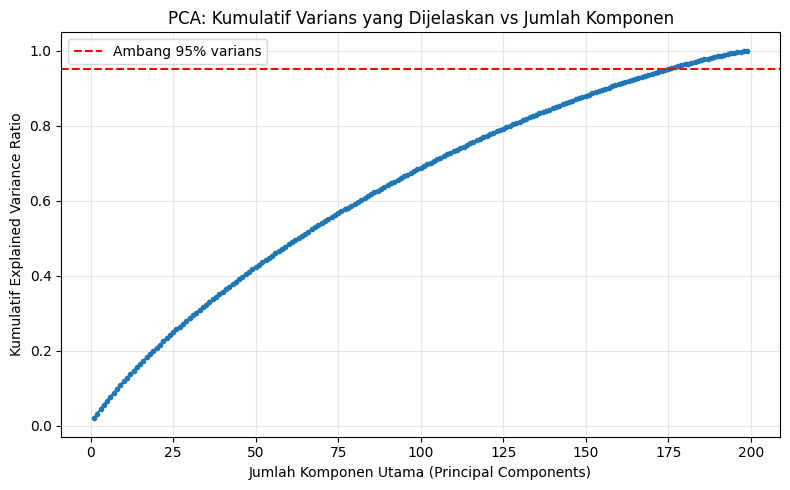

Jumlah komponen untuk mempertahankan >= 95% varians: 175 (dari semula 807 fitur/kata unik)


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# PCA bekerja pada matriks dense, sedangkan TF-IDF berbentuk sparse matrix -> ubah ke dense
tfidf_dense = tfidf_matrix.toarray()

# --- 4.1 Analisis Explained Variance ---
# Jumlah komponen maksimum dibatasi oleh min(jumlah dokumen, jumlah fitur)
n_komponen_maks = min(tfidf_dense.shape) - 1

pca_full = PCA(n_components=n_komponen_maks, random_state=42)
pca_full.fit(tfidf_dense)

variansi_kumulatif = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(variansi_kumulatif) + 1), variansi_kumulatif, marker='o', markersize=3)
plt.axhline(y=0.95, color='red', linestyle='--', label='Ambang 95% varians')
plt.xlabel('Jumlah Komponen Utama (Principal Components)')
plt.ylabel('Kumulatif Explained Variance Ratio')
plt.title('PCA: Kumulatif Varians yang Dijelaskan vs Jumlah Komponen')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Jumlah komponen minimum agar mempertahankan >= 95% varians
n_komponen_95 = int(np.argmax(variansi_kumulatif >= 0.95) + 1)
print(f"Jumlah komponen untuk mempertahankan >= 95% varians: {n_komponen_95} "
      f"(dari semula {tfidf_dense.shape[1]} fitur/kata unik)")


Total varians yang dijelaskan oleh 2 komponen pertama: 3.26%


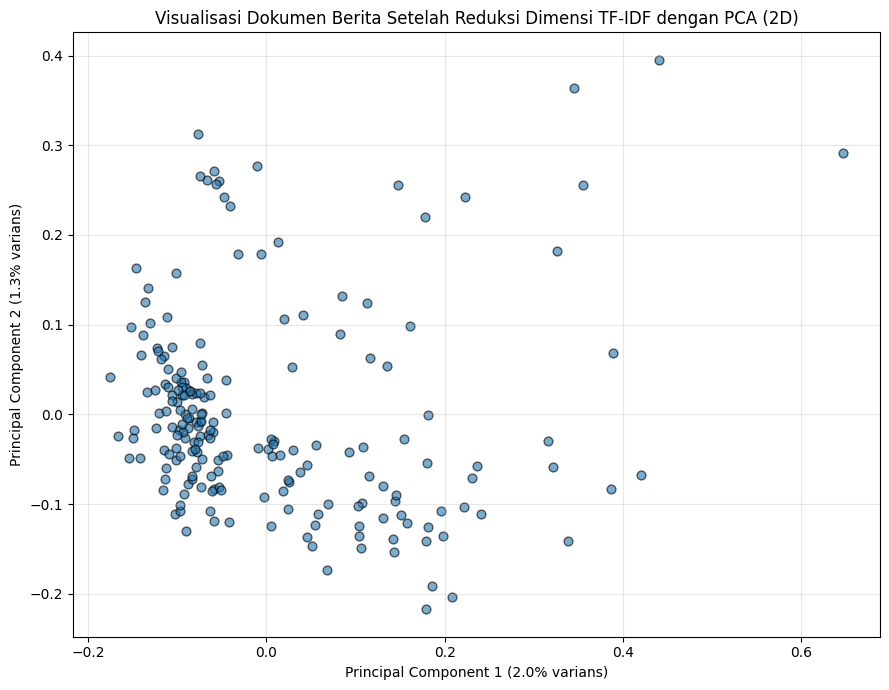

,PC1,PC2,Judul Berita
0,0.181585,-0.125541,"Susul Italia, Denmark Juga Di-lockdown Imbas V..."
1,0.419825,-0.067537,Mungkinkah Virus Corona Aktif Lagi Setelah Pas...
2,0.355429,0.255765,"Sebaran Kasus Corona RI 9 Juni, 11.414 Sembuh ..."
3,0.338734,-0.140722,"Kisah Pasien 03, Buka-bukaan Awal Tertular Vir..."
4,-0.080842,-0.030722,4 Variasi Seks Ketika Penetrasi Biasa Terasa M...
5,0.108490,-0.036110,Ibu dan Anak Berhasil Melarikan Diri dari Pusa...
6,0.002036,-0.038533,Pria Ini Bikin Sendiri Hazmat 'Anti Corona' da...
7,0.179923,-0.054069,Berapa Lama Virus Corona Bertahan di Dalam Tubuh?
8,-0.090114,-0.129994,Plus-Minus dan Hal Penting Lain Soal Masker Ka...
9,0.006050,-0.046072,"Viral Tegal Pesta Kembang Api, Berakhirnya PSB..."


In [6]:
# --- 4.2 Reduksi ke 2 Dimensi untuk Visualisasi ---
pca_2d = PCA(n_components=2, random_state=42)
tfidf_pca_2d = pca_2d.fit_transform(tfidf_dense)

df_pca_2d = pd.DataFrame(tfidf_pca_2d, columns=['PC1', 'PC2'])
df_pca_2d['Judul Berita'] = df_berita['Judul Berita'].values

print("Total varians yang dijelaskan oleh 2 komponen pertama: {:.2f}%".format(
    100 * pca_2d.explained_variance_ratio_.sum()
))

plt.figure(figsize=(9, 7))
plt.scatter(df_pca_2d['PC1'], df_pca_2d['PC2'], alpha=0.6, edgecolor='k', s=40)
plt.xlabel(f'Principal Component 1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% varians)')
plt.ylabel(f'Principal Component 2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% varians)')
plt.title('Visualisasi Dokumen Berita Setelah Reduksi Dimensi TF-IDF dengan PCA (2D)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

df_pca_2d.head(10)


In [7]:
# --- 4.3 (Opsional) Reduksi ke n komponen yang mempertahankan >= 95% varians ---
# Fitur hasil reduksi ini yang biasanya dipakai sebagai input model ML selanjutnya
# (misalnya clustering atau klasifikasi berita), karena dimensinya jauh lebih kecil
# dibanding matriks TF-IDF asli namun tetap mempertahankan sebagian besar informasi.

pca_final = PCA(n_components=n_komponen_95, random_state=42)
tfidf_pca_final = pca_final.fit_transform(tfidf_dense)

print("Dimensi TF-IDF sebelum PCA :", tfidf_dense.shape)
print("Dimensi setelah PCA        :", tfidf_pca_final.shape)
print("Total varians dipertahankan: {:.2f}%".format(
    100 * pca_final.explained_variance_ratio_.sum()
))

df_pca_final = pd.DataFrame(
    tfidf_pca_final,
    columns=[f'PC{i+1}' for i in range(tfidf_pca_final.shape[1])],
    index=[f"Doc {i+1}" for i in range(tfidf_pca_final.shape[0])]
)
df_pca_final.head(10)


Dimensi TF-IDF sebelum PCA : (200, 807)
Dimensi setelah PCA        : (200, 175)
Total varians dipertahankan: 95.13%


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC166,PC167,PC168,PC169,PC170,PC171,PC172,PC173,PC174,PC175
Doc 1,0.181580,-0.143775,0.016002,-0.139873,-0.164245,-0.078918,0.003980,0.046092,-0.064632,0.046781,...,0.029427,0.080115,0.000486,-0.006320,0.004574,0.009167,-0.016188,0.009265,0.008265,0.033748
Doc 2,0.419945,-0.046687,0.207633,0.179555,0.147249,-0.072524,0.182054,0.018448,0.100322,-0.049064,...,-0.087555,0.032028,-0.080916,-0.071948,-0.071504,0.026428,0.078856,0.044614,-0.034464,-0.102696
Doc 3,0.355289,0.267141,-0.081571,0.221291,-0.010260,0.074131,-0.067540,-0.118805,0.018055,0.257378,...,-0.058919,-0.002154,-0.014484,0.075737,-0.121734,0.046789,0.109392,0.047388,-0.002684,-0.026939
Doc 4,0.338922,-0.124948,0.159529,0.166934,0.170132,-0.072561,0.087893,-0.128389,-0.016212,-0.140891,...,-0.081251,0.020193,0.034961,0.038252,0.075923,-0.036534,-0.101249,-0.002569,0.054299,0.105781
Doc 5,-0.080800,-0.029854,-0.042677,0.028631,0.022283,-0.012546,-0.027093,-0.068512,-0.016757,-0.017505,...,-0.024342,0.003823,-0.025286,0.007800,-0.010627,0.017483,0.011703,-0.011754,0.017314,0.019116
Doc 6,0.108316,-0.037031,0.011882,-0.108332,-0.121248,0.049336,0.017352,0.011375,-0.016012,-0.110030,...,0.076844,-0.008175,-0.059731,-0.074735,-0.088703,-0.059372,-0.065028,0.018771,0.010140,-0.111991
Doc 7,0.001874,-0.043872,-0.078732,0.000305,-0.007157,0.045249,-0.038302,-0.054402,0.008941,0.000849,...,0.045584,-0.002879,-0.052331,-0.047525,0.008483,-0.008309,0.010990,-0.028030,-0.017631,-0.033773
Doc 8,0.179472,-0.030517,-0.003591,-0.213622,-0.209473,-0.039668,-0.038133,0.043884,0.143372,-0.161739,...,0.024162,-0.044875,0.067331,-0.037708,0.011109,-0.015094,0.001543,0.090470,0.010685,0.119232
Doc 9,-0.089413,-0.168570,-0.062883,0.076861,-0.066562,0.381741,0.117365,0.296442,-0.051698,-0.030169,...,-0.018836,-0.002245,0.003351,-0.110114,-0.022962,0.077323,-0.071242,0.078610,-0.129549,-0.079659
Doc 10,0.005648,-0.048091,-0.073568,-0.002746,-0.006883,-0.017708,-0.029336,-0.041286,0.033191,-0.048103,...,-0.001260,-0.031623,-0.000434,0.054582,-0.016871,-0.004733,-0.011376,-0.031183,0.021950,-0.015616


In [8]:
# =========================================================
# Menyimpan hasil ke CSV: (1) TF-IDF asli, (2) TF-IDF tereduksi PCA, (3) hasil PCA lengkap
# Kolom 'Kategori' disertakan sebagai TARGET (label kelas) untuk keperluan
# klasifikasi (mis. di Orange: drag kolom ini ke kotak "Target").
# =========================================================

# 1. Matriks TF-IDF asli (dokumen x kata unik) + judul berita & kategori sebagai referensi
df_tfidf_export = df_tfidf.copy()
df_tfidf_export.insert(0, 'Kategori', df_berita['Kategori'].values)
df_tfidf_export.insert(0, 'Judul Berita', df_berita['Judul Berita'].values)
df_tfidf_export.to_csv('tfidf_hasil.csv', index=False)
print("Tersimpan: 'tfidf_hasil.csv' ->", df_tfidf_export.shape)

# 2. TF-IDF yang SUDAH DIREDUKSI dengan PCA (n_komponen_95, mempertahankan >=95% varians)
df_tfidf_reduksi = pd.DataFrame(
    tfidf_pca_final,
    columns=[f'PC{i+1}' for i in range(tfidf_pca_final.shape[1])]
)
df_tfidf_reduksi.insert(0, 'Kategori', df_berita['Kategori'].values)
df_tfidf_reduksi.insert(0, 'Judul Berita', df_berita['Judul Berita'].values)
df_tfidf_reduksi.to_csv('tfidf_tereduksi_pca.csv', index=False)
print("Tersimpan: 'tfidf_tereduksi_pca.csv' ->", df_tfidf_reduksi.shape,
      f"(dari semula {tfidf_dense.shape[1]} kolom TF-IDF menjadi {tfidf_pca_final.shape[1]} kolom PCA)")

# 3. Hasil PCA lengkap (versi final 95% varians + kolom PC1/PC2 dari versi 2D untuk plotting)
df_pca_export = df_pca_final.copy()
df_pca_export.insert(0, 'Kategori', df_berita['Kategori'].values)
df_pca_export.insert(0, 'Judul Berita', df_berita['Judul Berita'].values)
df_pca_export.insert(2, 'PC1_2D', df_pca_2d['PC1'].values)
df_pca_export.insert(3, 'PC2_2D', df_pca_2d['PC2'].values)
df_pca_export.to_csv('pca_hasil.csv', index=False)
print("Tersimpan: 'pca_hasil.csv'   ->", df_pca_export.shape)

Tersimpan: 'tfidf_hasil.csv' -> (200, 809)
Tersimpan: 'tfidf_tereduksi_pca.csv' -> (200, 177) (dari semula 807 kolom TF-IDF menjadi 175 kolom PCA)
Tersimpan: 'pca_hasil.csv'   -> (200, 179)


### Ringkasan

| Tahap | Input | Output |
|---|---|---|
| Crawling | Halaman web Detik Health | `df_berita` (Judul Berita, Tautan) |
| Preprocessing | `df_berita['Judul Berita']` | `df_berita['teks_bersih']` |
| Ekstraksi Fitur | Korpus teks bersih | `vocabulary` (seluruh kata unik) |
| TF-IDF | Korpus + vocabulary | `tfidf_matrix` (dokumen x kata unik) |
| PCA | `tfidf_matrix` | Matriks berdimensi rendah (2D untuk visualisasi, atau *n* komponen untuk mempertahankan >=95% varians) |

Dengan pipeline ini, data berita mentah hasil *crawling* telah berhasil diubah menjadi representasi numerik (TF-IDF) yang siap digunakan untuk tahap lanjutan seperti *clustering* berita atau klasifikasi topik, dengan dimensi yang telah direduksi menggunakan PCA agar lebih efisien secara komputasi.